# Тестовое задание на позицию аналитика данных в Яндекс команду поддержки бизнеса

**описание данных**: таблица с информацией по обращениям (тикетами)
- **action**	действие внутри обращения
- **action_author_group**	кто совершил действие
- **action_csat_reasons_text**	причина проставления csat
- **action_csat_text**	оценка диалога csat (от 1 до 5)
- **action_line**	линия, на которой была работа по обращению
- **dttm_action**	время действия
- **dttm_ticket_created**	время создания обращения
- **hash_ticket**	зашифрованный номер тикета (обращения)
- **theme_without_level**	Тематика обращения без разделения по уровням


**Цель** - ответить на вопросы по этим данным.

**Вопросы**:

1) Можно ли посчитать сколько обращений было за месяц? Если да, то сколько?

2) Сколько обработанных обращений было с 1 по 3 июня? 

3) Сколько новых обращений было с 1 по 3 июня?

4) По какой тематике 1 уровня больше всего обращений?

5) Какие пиковые часы поступления обращений?
 
6) Сколько в среднем действий совершается в рамках одного тикета?

7*) Какой средний ксат?

8**) На какой процент тикетов отвечает только ml?

Решать можно любым способом: excel, sql, python, datalens.

*используем в этом отчете python и sql*

## Импорт данных и библиотек

In [1]:
!pip install openpyxl -q

In [2]:
import numpy as np
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt


Берем вторй лист ексель файла. Второй строкой у нас указан тип данных, но в анализе данных это будет мешать, приведем датафрейм к стандартному виду

In [3]:
df = pd.read_excel(r"C:/Users/79533/Desktop/test/task.xlsx", sheet_name=1,skiprows=[1])
df.head()

,action,action_author_group,action_csat_reasons_text,action_csat_text,action_line,dttm_action,dttm_ticket_created,hash_ticket,theme_without_level
0,communicate,Operator,non background,5,market_second_online,2022-06-03T16:16:47Z,2022-03-03T18:11:31Z,12486122957333899977,Лояльность::Плюс
1,forward,Operator,non background,5,market_second_online,2022-06-03T16:17:00Z,2022-03-03T18:11:31Z,12486122957333899977,Лояльность::Плюс
2,communicate,Operator,non background,5,market_not_received,2022-06-03T15:25:29Z,2022-03-04T09:34:26Z,2912553028357548622,Другое::Временный ответ
3,close,Operator,non background,5,market_not_received,2022-06-03T15:29:41Z,2022-03-04T09:34:26Z,2912553028357548622,Доставка::Срок доставки::Доставим вовремя
4,reopen,ML,non background,5,market_not_received,2022-06-03T16:06:36Z,2022-03-04T09:34:26Z,2912553028357548622,NaN


## Предобработка данных

**общая информация**

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 565234 entries, 0 to 565233
Data columns (total 9 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   action                    565234 non-null  str   
 1   action_author_group       565234 non-null  str   
 2   action_csat_reasons_text  447080 non-null  str   
 3   action_csat_text          565234 non-null  int64 
 4   action_line               565234 non-null  str   
 5   dttm_action               565234 non-null  str   
 6   dttm_ticket_created       547486 non-null  str   
 7   hash_ticket               565234 non-null  uint64
 8   theme_without_level       94897 non-null   str   
dtypes: int64(1), str(7), uint64(1)
memory usage: 38.8 MB


Всего 565234 строк, разные типы данных. (Кстати было указано int 32, по факту int 64 в action_csat_text	).

dttm_action и dttm_ticket_created стоит перевести в формат дататайм

uint64 тп данных для больших положительных чисел. В аналитике хэш часто переводят как строку, т.к это идентификатор, а не число для вычислений. 

Есть пропуски

**типы данных**

In [5]:
df["dttm_action"] = pd.to_datetime(df["dttm_action"])
df["dttm_ticket_created"] = pd.to_datetime(df["dttm_ticket_created"])

In [6]:
print(df["dttm_action"].dt.tz)
print(df["dttm_ticket_created"].dt.tz)

UTC
UTC


все строки имеют tzinfo = UTC, то это одна и та же временная зона (00:00). Можем ее отбросить

In [7]:
df["dttm_action"] = df["dttm_action"].dt.tz_convert(None)
df["dttm_ticket_created"] = df["dttm_ticket_created"].dt.tz_convert(None)


In [8]:
df.head(2)

,action,action_author_group,action_csat_reasons_text,action_csat_text,action_line,dttm_action,dttm_ticket_created,hash_ticket,theme_without_level
0,communicate,Operator,non background,5,market_second_online,2022-06-03 16:16:47,2022-03-03 18:11:31,12486122957333899977,Лояльность::Плюс
1,forward,Operator,non background,5,market_second_online,2022-06-03 16:17:00,2022-03-03 18:11:31,12486122957333899977,Лояльность::Плюс


Переведем хэш в строку

In [9]:
df["hash_ticket"] = df["hash_ticket"].astype("str")

**Дубликаты**

In [10]:
df.duplicated().sum()

np.int64(20)

У нас 20 дубликатов, посмотрим на них

In [11]:
df[df.duplicated(keep=False)].head(6)

,action,action_author_group,action_csat_reasons_text,action_csat_text,action_line,dttm_action,dttm_ticket_created,hash_ticket,theme_without_level
6943,waiting_operator,Client,NaN,-1,market_second_online,2022-06-03 12:36:22,2022-05-31 21:15:57,6426886200632721094,NaN
6944,waiting_operator,Client,NaN,-1,market_second_online,2022-06-03 12:36:22,2022-05-31 21:15:57,6426886200632721094,NaN
6945,waiting_operator,Client,NaN,-1,market_second_online,2022-06-03 12:36:23,2022-05-31 21:15:57,6426886200632721094,NaN
6946,waiting_operator,Client,NaN,-1,market_second_online,2022-06-03 12:36:23,2022-05-31 21:15:57,6426886200632721094,NaN
6958,waiting_operator,Client,NaN,-1,market_second_online,2022-06-03 12:42:44,2022-05-31 21:15:57,6426886200632721094,NaN
6959,waiting_operator,Client,NaN,-1,market_second_online,2022-06-03 12:42:44,2022-05-31 21:15:57,6426886200632721094,NaN


Это полные дубликаты с совпадением хэша, даты-времени и других параметров. Удалим их

In [12]:
df = df.drop_duplicates()

**Опечатки и разночтения**

In [13]:
cat_cols = df.select_dtypes(include=['object','string']).columns

In [14]:
for col in cat_cols:
    print()
    print (col)
    display(df[col].sort_values().unique())


action


<StringArray>
[              'bridged',                 'close',               'comment',
           'communicate',             'completed',                'create',
           'create_call',   'create_extra_ticket',        'csat_receiving',
                 'defer',               'dismiss',               'forward',
        'hidden_comment', 'macro_processing_fail',                'reopen',
      'waiting_operator']
Length: 16, dtype: str


action_author_group


<StringArray>
['Client', 'ML', 'Operator']
Length: 3, dtype: str


action_csat_reasons_text


...

<StringArray>
[                        'mail',      'market_b2b_forward_chat',
            'market_baby_skill',          'market_calls_israel',
            'market_consult_l1',                  'market_corp',
          'market_corp_cabinet',         'market_courier_phone',
               'market_express',          'market_first_online',
        'market_incoming_calls',    'market_incoming_calls_b2c',
                 'market_kb_l2',        'market_logsupp_online',
                  'market_mail',         'market_mail_feedback',
           'market_ml_razmetka',          'market_not_received',
      'market_online_superchat',          'market_political_l2',
     'market_proaktiv_2perenos', 'market_proaktiv_order_cancel',
              'market_received',           'market_reoprn_test',
               'market_reorder',          'market_return_calls',
         'market_second_online',              'market_services',
            'market_trade_mark',                'market_urgent',
       'mar


hash_ticket


<StringArray>
['10000036835503100144', '10000071270897291577', '10000150792089284698',
 '10000157962407525551',  '1000046241729361971', '10000481424888930337',
 '10000803987231202662', '10000835136397468270', '10001006103038582371',
 '10001006995791555368',
 ...
  '9999424805448327813',  '9999486392444005410',  '9999529673412583008',
  '9999628157786710477',  '9999629921277024063',  '9999785600317311138',
  '9999851194278153166',  '9999884139339345682',  '9999981586355135265',
  '9999992412758647217']
Length: 167434, dtype: str


theme_without_level


<StringArray>
[                                          'Аккаунт',
                'Аккаунт::Авторизация и регистрация',
   'Аккаунт::Авторизация и регистрация::Авторизация',
   'Аккаунт::Авторизация и регистрация::Регистрация',
                             'Аккаунт::Коммуникации',
             'Аккаунт::Коммуникации::Email-рассылки',
           'Аккаунт::Коммуникации::Push-уведомления',
                               'Аккаунт::Мои заказы',
              'Аккаунт::Мои заказы::Привязать заказ',
     'Аккаунт::Мои заказы::Удалить заказ из истории',
 ...
                                 'Сервис::Пожелания',
                              'Сервис::Рекомендации',
                                  'Сервис::Советник',
          'Сервис::Сотрудничество и трудоустройство',
                           'Сервис::Чат с продавцом',
                             'Сервис::Яндекс Мастер',
                                'Техническая ошибка',
          'Техническая ошибка::Неизвестная проблема',
 'Техниче

В action_csat_reasons_text только 'non background' отличается форматом (пробел вместо _) от других, но это скорее внутренняя спецификация системы.

В action_line 'market_reoprn_test' возможно 'market_reopen_test', но для того чтобы понять есть ли разночтения нужно знать что означает каждое обозначение

theme_without_level похоже на иерархию тем обращения, где уровни разделены ::. Короткие темы только первого уровня: Аккаунт,Сервис, Техническая ошибка

In [15]:
themes = df["theme_without_level"].dropna().str.strip()

Опечтаки встречаются редко,поэтому проверим редкие строки

In [16]:
themes.value_counts().sort_values().head(20)

theme_without_level
Сервис::Карточка товара::Некорректная категория                                   1
Оплата::Рассрочка::Почему способ недоступен                                       1
Возврат::Товар надлежащего качества::Ювелирные изделия                            2
Оплата::Рассрочка::Условия                                                        2
Возврат::Способ возврата::Постаматы                                               2
Аккаунт::Коммуникации                                                             3
Лояльность::Кешбэк::Кешбэк за первый заказ                                        3
Доставка::Примерка::Отказали в примерке                                           3
Сервис::Карточка товара::Некачественное изображение                               3
Сервис::Жалобы::Жалоба на упаковку (DBS)                                          4
Лояльность::Купон::Недоволен купоном                                              4
Сервис::Советник                                        

Пока что считаем что опечаток нет

**Пропуски**

In [17]:
df.isna().sum().sort_values(ascending=False)

theme_without_level         470317
action_csat_reasons_text    118143
dttm_ticket_created          17747
action                           0
action_author_group              0
action_line                      0
action_csat_text                 0
dttm_action                      0
hash_ticket                      0
dtype: int64

round(df.isna().mean().sort_values(ascending=False) * 100,2).head(4)

У нас пропуски в трех столбцах. 

Меньше всего пропусков - время создания обращения(~3%). Можно заполнить минимальной датой в тикете из dttm_action (тогда время отклика для этих 3% будет считаться некорректно) или удалить 3% данных

Около 21% пропусков оценка диалога csat (CSAT = Customer Satisfaction Score). Заполнять медианой или средним не вариант, можно сильно исказить результат. Можно поставить заглушку, но пока оставим пропуски как есть. 

В тематика обращения без разделения по уровням всего 16,3% данных. Восстановить пропуски по другим каолонкам мы не можем, поэтому будем составлять топ тематик по тому что имеем


в dttm_ticket_created заполним пропуски минимальной датой dttm_action. Да,это не на сто процентов корректно (т.к. дата действия с обращением всегда чуть позже самого обращения) 

найдем минимальное время взаимодействия по тикету:

In [18]:
first_action = df.groupby("hash_ticket")["dttm_action"].min().reset_index(name="created_guess")

добавим столбец в нашу исходную таблицу

In [19]:
df = df.merge(first_action, on="hash_ticket", how="left")

и заполним наши пропуски из этого столбца

In [20]:
df["dttm_ticket_created"] = df["dttm_ticket_created"].fillna(df["created_guess"])
df.drop(columns="created_guess", inplace=True)

Также переведем нашу таблицу в sql, чтобы можно было работать и через sqllite и через пандас

In [21]:
conn = sqlite3.connect(":memory:")
df.to_sql("tickets", conn, index=False, if_exists="replace")

565214

## Ответы на вопросы

### Можно ли посчитать сколько обращений было за месяц? Если да, то сколько?

Если посчитать количество уникальных тикетов (hash_ticket) по месяцу, то можно сделать через dttm_ticket_created (время создания обращения).

в пандас:

In [22]:
df1=df.copy()
df1["year_month"] = df1["dttm_ticket_created"].dt.to_period("M")

Считаем количество тикетов по месяцам

In [23]:
tickets_per_month_pd = df1.groupby("year_month")["hash_ticket"].nunique().reset_index(name="num_tickets")
tickets_per_month_pd

,year_month,num_tickets
0,2021-12,1
1,2022-01,8
2,2022-02,11
3,2022-03,46
4,2022-04,91
5,2022-05,1738
6,2022-06,165539


В SQL (пишем запрос с учетом того, что у нас SQLite)

In [24]:
query = """
SELECT 
    strftime('%Y-%m', dttm_ticket_created) AS month,
    COUNT(DISTINCT hash_ticket) AS num_tickets
FROM tickets
WHERE dttm_ticket_created IS NOT NULL
GROUP BY month
ORDER BY month
"""

tickets_per_month = pd.read_sql_query(query, conn)

tickets_per_month

,month,num_tickets
0,2021-12,1
1,2022-01,8
2,2022-02,11
3,2022-03,46
4,2022-04,91
5,2022-05,1738
6,2022-06,165539


Мы видим, увеличение количества запросов в каждом месяце и очень большой рост в последнем месяце. Визуализируем

In [25]:
tickets_per_month["month"] = pd.to_datetime(tickets_per_month["month"])

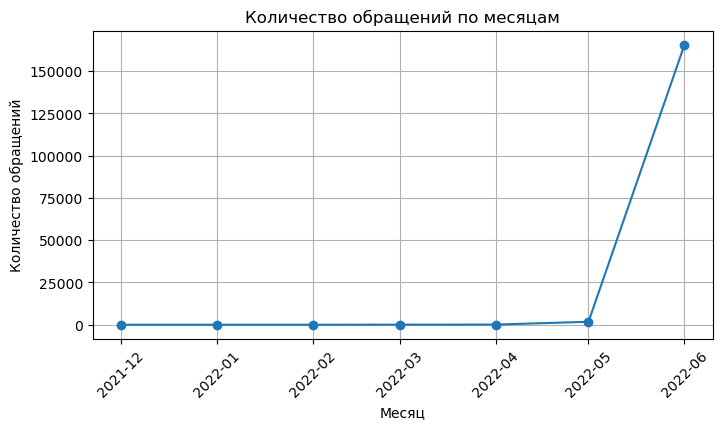

In [26]:
plt.figure(figsize=(8,4))
plt.plot(tickets_per_month["month"], tickets_per_month["num_tickets"], marker='o')

plt.title("Количество обращений по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Количество обращений")

plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Увеличесние количества обращений в последнем месяце относительно предыдущего в > 95 раз
Такой рост выглядит аномальным, это возможно если произошло массовое подключение пользователей или начался автоматический поток тикетов, или данные до мая просто неполные. 

Проверим количество строк. 

In [27]:
query = """
SELECT 
    strftime('%Y-%m', dttm_ticket_created) AS month,
    COUNT(*) AS rows_count,
    COUNT(DISTINCT hash_ticket) AS tickets_count
FROM tickets
GROUP BY month
ORDER BY month
"""

pd.read_sql_query(query, conn)

,month,rows_count,tickets_count
0,2021-12,2,1
1,2022-01,24,8
2,2022-02,31,11
3,2022-03,122,46
4,2022-04,174,91
5,2022-05,8366,1738
6,2022-06,556495,165539


Видно, что количество строк тоже растет. Скорее всего декабрь–апрель — неполный период,а реальные данные начинаются с мая или июня

## Сколько обработанных обращений было с 1 по 3 июня?

Такой запрос тоже очень удобно вышuрузить через SQL.
обработанными будем считать обращения со статусом closed. Укажем период и посчитаем количество уникальных хэш. 


In [28]:
query = """
SELECT COUNT(DISTINCT hash_ticket) AS closed_tickets
FROM tickets
WHERE action = 'close'
AND dttm_action >= '2022-06-01'
AND dttm_action <  '2022-06-04'
"""

In [29]:
closed_tickets = pd.read_sql_query(query, conn)

closed_tickets

,closed_tickets
0,35590


В период с 1 по 3 июня было обработано 35590 обращений
 

## Сколько новых обращений было с 1 по 3 июня?

Для подсчета новых обращений испрользуем колонку dttm_ticket_created с датой создания обращения

In [30]:
query = """
SELECT COUNT(DISTINCT hash_ticket) AS new_tickets
FROM tickets
WHERE dttm_ticket_created >= '2022-06-01'
  AND dttm_ticket_created <  '2022-06-04'
"""

new_tickets = pd.read_sql_query(query, conn)

In [31]:
new_tickets

,new_tickets
0,165539


## По какой тематике 1 уровня больше всего обращений?

Тематика 1 уровня - это часть строки до первого ::. Добавим в df столбец с тематикой первого уровня (можно через split, но partition займет чуть меньше памяти)

In [32]:
df['theme_level_1'] = df['theme_without_level'].str.partition('::')[0]

In [33]:
level_1_counts = df['theme_level_1'].value_counts()

level_1_counts

theme_level_1
Доставка              33044
Возврат               13854
Оплата                 9260
Другое                 7364
Отмена заказа          7182
Оформление заказа      7091
Лояльность             6625
Техническая ошибка     4348
Аккаунт                3260
Сервис                 2869
Name: count, dtype: int64

всего у нас 10 тем 1 уровня, наиболее популярная "Доставка" (33 тыс обращений). Визуализирем для наглядности

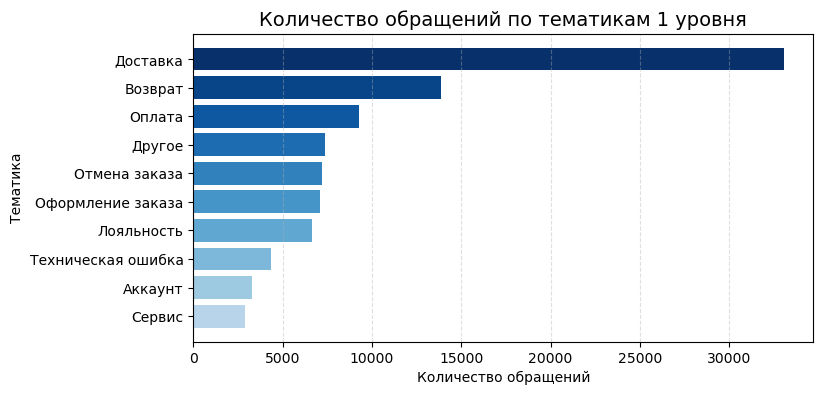

In [34]:
level_1_counts = level_1_counts.sort_values()
colors = plt.cm.Blues(np.linspace(0.3, 1, len(level_1_counts)))

plt.figure(figsize=(8,4))
plt.barh(level_1_counts.index, level_1_counts.values, color=colors)

plt.title('Количество обращений по тематикам 1 уровня', fontsize=14)
plt.xlabel('Количество обращений')
plt.ylabel('Тематика')
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()

Количество обращений с темой 1 уровня "Доставка" превышает остальные более чем в 2 раза.

## Какие пиковые часы поступления обращений?

Выделим час из даты-времени создания обращения в отдельный столбец

In [35]:
df["hour"] = df["dttm_ticket_created"].dt.hour

Нам нужно взять ункальные хэши, чтобы одно обращение не учитывалось несколько раз из-за истории действий с ним.

In [36]:
tickets_by_hour = (df.groupby("hour")["hash_ticket"].nunique().reset_index(name="tickets_count").sort_values("hour"))


5 пиковых часов запросов

In [37]:
tickets_by_hour.sort_values(by='tickets_count', ascending=False).head(5)

,hour,tickets_count
17,17,28138
13,13,16777
15,15,16516
21,21,16130
18,18,15442


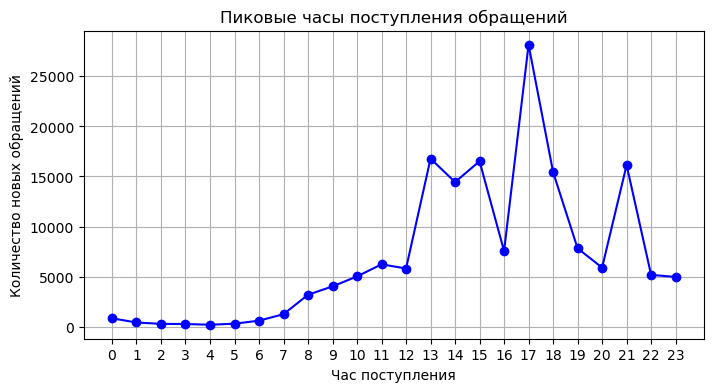

In [38]:
plt.figure(figsize=(8,4))
plt.plot(tickets_by_hour["hour"], tickets_by_hour["tickets_count"], marker='o', color='blue')
plt.xticks(range(0,24))
plt.xlabel("Час поступления")
plt.ylabel("Количество новых обращений")
plt.title("Пиковые часы поступления обращений")
plt.grid(True)
plt.show()

Мы видим что наибольшее количество обращений происходит во временной период с часу дня до 9 вечера. При этом с 7-8 вечера наблюдается спад. Максимальное число обращений в 17:00. Ночной и утренний период довольно спокойные: с 0 до 6 утра количество обращений минимальное, с 7 до 12 начинается плавный рост. 

Можно выделить несколько пиков: 
основной в 17:00, дополнительные 13,15,21:00

## Сколько в среднем действий совершается в рамках одного тикета?

Сгруппируем по хэшу и посчитаем среднее количество action (действий внутри обращения)

In [39]:
actions_per_ticket = df.groupby("hash_ticket").size()
average_actions = round(actions_per_ticket.mean(),2)
print("Среднее количество действий на тикет:", average_actions)

Среднее количество действий на тикет: 3.38


В среднем с каждым тикетом совершается около 3 действий


также просто реализовать через sql c подзапросом

In [40]:
query = """
SELECT AVG(actions_count) AS avr_act_per_ticket
FROM (SELECT hash_ticket, COUNT(*) AS actions_count
    FROM tickets
    GROUP BY hash_ticket) sub
"""

In [41]:
avr_actions = pd.read_sql_query(query, conn)
print(avr_actions)

   avr_act_per_ticket
0            3.375742


## Какой средний ксат?

In [42]:
df.action_csat_text.unique()

array([ 5, -1,  4,  3,  1,  2])

Оценка диалога csat (от 1 до 5). У нас есть значение-заглушка -1 в тех строках, где оценка не была проставлена. Чтобы правильно посчитать средний CSAT, нужно исключить -1, иначе среднее будет некорректным. Заменим -1 на NaN, тогда pandas будет игнорировать их при подсчёте среднего

In [43]:
df["real_scat"] = df["action_csat_text"].replace(-1, np.nan)

In [44]:
mean_scat = round(df["real_scat"].mean(),3)
mean_scat

np.float64(3.982)

Если округлить грубо, то можно сказать, что средняя оценка scat около 4

## На какой процент тикетов отвечает только ml

Здесь важна интерпретация вопросы. Мы будем искать тикеты, где все действия совершены исключительно ML, и нет ни одного действия оператора.

In [45]:
df['action_author_group'].unique()

<StringArray>
['Operator', 'ML', 'Client']
Length: 3, dtype: str

Сгруппируем по хэшу. Для каждого хэша смотрим всех авторов действий, проверяем, есть ли только ML. Посчитаем количество таких тикетов, разделим на общее количество тикетов, чтобы получить процент.

Создадим стоблец с флагом где ответ совершен ML

In [46]:
df['is_ml'] = df['action_author_group'] == 'ML'

Группируем по хэшу и проверяем где все действия совершил мл

In [47]:
ml_only = df.groupby('hash_ticket')['is_ml'].all()

Считаем процент

In [48]:
percent_ML = (ml_only.sum()/ml_only.count())*100
percent_ML

np.float64(61.197247870802826)

In [49]:
ml_stats = ml_only.value_counts()

In [50]:
ml_stats

is_ml
True     102465
False     64969
Name: count, dtype: int64

индексы переименуем явно, чтобы избежать путаницы

In [51]:
ml_stats.index = ml_stats.index.map({True: 'Только ML', False: 'Остальные'})

In [52]:
ml_percent = (ml_stats / ml_stats.sum() * 100).round(1)

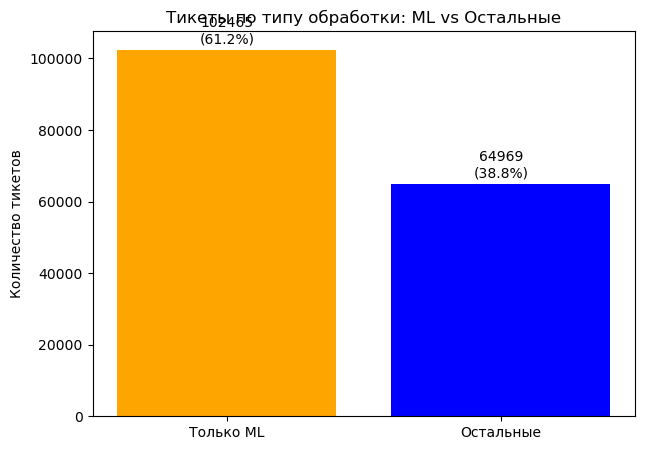

In [53]:
plt.figure(figsize=(7,5))
bars = plt.bar(ml_stats.index, ml_stats.values, color=['orange','blue'])

plt.ylabel('Количество тикетов')
plt.title('Тикеты по типу обработки: ML vs Остальные')

for bar, count, perc in zip(bars, ml_stats.values, ml_percent.values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1000, f"{count}\n({perc}%)", 
             ha='center', va='bottom', fontsize=10)

plt.show()

## Выводы

1)  Мы видим, увеличение количества запросов в каждом месяце и очень большой рост в последнем месяце. Скорее всего декабрь–апрель — неполный период,а реальные данные начинаются с мая или июня

2)  В период с 1 по 3 июня было обработано 35590 обращений

3) Количество новых обращений в период с 1 по 3 июня 165539

4) Количество обращений с темой 1 уровня "Доставка" превышает остальные более чем в 2 раза (33044 обращений).

5) Наибольшее количество обращений происходит во временной период с 13 до 21. При этом в период 19-20  наблюдается спад. Ночной и утренний период довольно спокойные: с 0 до 6 утра количество обращений минимальное, с 7 до 12 начинается плавный рост.
**Можно выделить несколько пиков: основной в 17:00, дополнительные 13,15,21:00**

6) В среднем с каждым обращением выполняется около 3-4 действий (ближе к 3)

7) При грубом округлении средняя оценка scat около 4 (3,98)

8) Только ML отвечает примерно на 61,2% обращений